In [ ]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

print("dr")

dr


In [ ]:
def make_task(perm, train_ds, test_ds):
    def loader(ds, shuffle):
        def collate(batch):
            x = torch.stack([img.view(-1)[perm] for img, _ in batch])
            y = torch.tensor([lbl for _, lbl in batch])
            return x, y
        return DataLoader(ds, BATCH, shuffle=shuffle, collate_fn=collate)
    return loader(train_ds, True), loader(test_ds, False)


def make_model():
    return torch.nn.Sequential(
        torch.nn.Linear(784, HIDDEN), torch.nn.ReLU(),
        torch.nn.Linear(HIDDEN, HIDDEN), torch.nn.ReLU(),
        torch.nn.Linear(HIDDEN, 10),
    ).to(device)


def compute_fisher(model, loader):
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    model.eval()
    for x, y in loader:
        model.zero_grad() 
        F.nll_loss(F.log_softmax(model(x.to(device)), 1), y.to(device)).backward()
        for n, p in model.named_parameters():
            if p.grad is not None:
                fisher[n] += p.grad.detach() ** 2
    return {n: v / len(loader) for n, v in fisher.items()}





def train_epoch(model, loader, opt, method, lam, old_snaps=None, fisher=None):
   
    model.train()
    for x, y in loader:
        opt.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))

        if method == 'ewc' and old_snaps is not None:
            penalty = sum(
                (fisher[n] * (p - old_snaps[n]).pow(2)).sum()
                for n, p in model.named_parameters()
            )
            loss += (lam / 2) * penalty

        elif method == 'l2' and old_snaps:
            penalty = sum(
                (p - snap[n]).pow(2).sum()
                for snap in old_snaps
                for n, p in model.named_parameters()
            )
            loss += (lam / 2) * penalty

        loss.backward()
        opt.step()

def accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            correct += (model(x.to(device)).argmax(1) == y.to(device)).sum().item()
            total   += len(y)
    return correct / total

# ── Cross-validation for lambda ───────────────────────────────
def cv_lambda(method, task0_train, task0_test, task1_train, task1_test, lam_grid):
    """
    Train on task 0, then for each lambda candidate:
      - fine-tune a copy of the model on task 1 for CV_EPOCHS epochs
      - measure accuracy on task 0 test set (catastrophic forgetting proxy)
    Returns best_lam and a dict {lam: acc_task0} for inspection.
    """
    print(f"\n  [{method.upper()}] Cross-validation pour lambda …")

    # 1. Train base model on task 0
    torch.manual_seed(SEED)
    base_model = make_model()
    opt0 = optim.Adam(base_model.parameters(), lr=LR)
    base_fisher = None
    for _ in range(EPOCHS):
        train_epoch(base_model, task0_train, opt0, 'sgd', lam=0)

    base_snap = {n: p.clone().detach() for n, p in base_model.named_parameters()}
    if method == 'ewc':
        base_fisher = compute_fisher(base_model, task0_train)

    # 2. For each lambda, fine-tune on task 1, measure acc on task 0
    scores = {}
    for lam in lam_grid:
        # Deep-copy weights from the trained base model
        trial_model = make_model()
        trial_model.load_state_dict(base_model.state_dict())
        opt_trial = optim.Adam(trial_model.parameters(), lr=LR)

        for _ in range(CV_EPOCHS):
            if method == 'ewc':
                train_epoch(trial_model, task1_train, opt_trial, 'ewc',
                            lam=lam, old_snaps=base_snap, fisher=base_fisher)
            else:  # l2
                train_epoch(trial_model, task1_train, opt_trial, 'l2',
                            lam=lam, old_snaps=[base_snap])

        acc0 = accuracy(trial_model, task0_test)
        acc1 = accuracy(trial_model, task1_test)
        acc = (acc0 + acc1)/2
        scores[lam] = acc
        print(f"      λ={lam:6.1f}  →  acc task0={acc0:.4f}; acc task1={acc1:.4f} -> mean acc={acc:.4f}")

    best_lam = max(scores, key=scores.get)
    print(f"  ✓ Best λ = {best_lam}  (acc task0 = {scores[best_lam]:.4f})")
    return best_lam, scores



In [8]:

EPOCHS = 10
BATCH  = 256
LR     = 1e-3
HIDDEN = 400
SEED   = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'
N_SAMPLES = 20000   # None = full dataset

# Lambda grids searched during CV
LAM_GRID = [0.1, 0.5, 1, 5, 10, 15, 30, 50, 100]
# Epochs used inside CV to evaluate each lambda candidate (cheaper than EPOCHS)
CV_EPOCHS = 3

#dataset creation 
torch.manual_seed(SEED)
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_ds = datasets.MNIST('./data', train=True,  download=True, transform=tf)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=tf)
if N_SAMPLES is not None:
    indices = torch.randperm(len(train_ds))[:N_SAMPLES]
    train_ds = Subset(train_ds, indices.tolist())
tasks = [make_task(p, train_ds, test_ds) for p in
         [torch.arange(784), torch.randperm(784), torch.randperm(784)]]

In [10]:
# ── Cross-validate lambdas ────────────────────────────────────
print("=" * 55)
print("Phase 1 : Cross-validation des lambdas")
print("=" * 55)

task0_train, task0_test = tasks[0]
task1_train, task1_test = tasks[1]

best_lam_l2,  cv_scores_l2  = cv_lambda('l2',  task0_train, task0_test, task1_train, task1_test,LAM_GRID)
best_lam_ewc, cv_scores_ewc = cv_lambda('ewc', task0_train, task0_test, task1_train, task1_test, LAM_GRID)

# Final lambdas (SGD has no regularisation)
LAM = {'sgd': 0, 'l2': best_lam_l2, 'ewc': best_lam_ewc}
print(f"\nLambdas retenus : {LAM}")


Phase 1 : Cross-validation des lambdas

  [L2] Cross-validation pour lambda …
      λ=   0.1  →  acc task0=0.9663; acc task1=0.9107 -> mean acc=0.9385
      λ=   0.5  →  acc task0=0.9671; acc task1=0.8374 -> mean acc=0.9022
      λ=   1.0  →  acc task0=0.9696; acc task1=0.7408 -> mean acc=0.8552
      λ=   5.0  →  acc task0=0.9692; acc task1=0.5106 -> mean acc=0.7399
      λ=  10.0  →  acc task0=0.9711; acc task1=0.3738 -> mean acc=0.6724
      λ=  15.0  →  acc task0=0.9701; acc task1=0.3010 -> mean acc=0.6355
      λ=  30.0  →  acc task0=0.9713; acc task1=0.2079 -> mean acc=0.5896
      λ=  50.0  →  acc task0=0.9717; acc task1=0.1396 -> mean acc=0.5556
      λ= 100.0  →  acc task0=0.9716; acc task1=0.1111 -> mean acc=0.5413
  ✓ Best λ = 0.1  (acc task0 = 0.9385)

  [EWC] Cross-validation pour lambda …
      λ=   0.1  →  acc task0=0.9470; acc task1=0.9607 -> mean acc=0.9538
      λ=   0.5  →  acc task0=0.9493; acc task1=0.9621 -> mean acc=0.9557
      λ=   1.0  →  acc task0=0.9540; acc


Phase 2 : Expérience complète (3 tâches)

SGD  (λ=0)
  Phase 1 done — final accs: ['0.97', '0.10', '0.06']
  Phase 2 done — final accs: ['0.85', '0.97', '0.11']
  Phase 3 done — final accs: ['0.49', '0.82', '0.97']

L2  (λ=0.1)
  Phase 1 done — final accs: ['0.97', '0.10', '0.06']
  Phase 2 done — final accs: ['0.97', '0.91', '0.08']
  Phase 3 done — final accs: ['0.97', '0.58', '0.88']

EWC  (λ=10000)
  Phase 1 done — final accs: ['0.97', '0.10', '0.06']
  Phase 2 done — final accs: ['0.93', '0.97', '0.14']
  Phase 3 done — final accs: ['0.76', '0.93', '0.97']


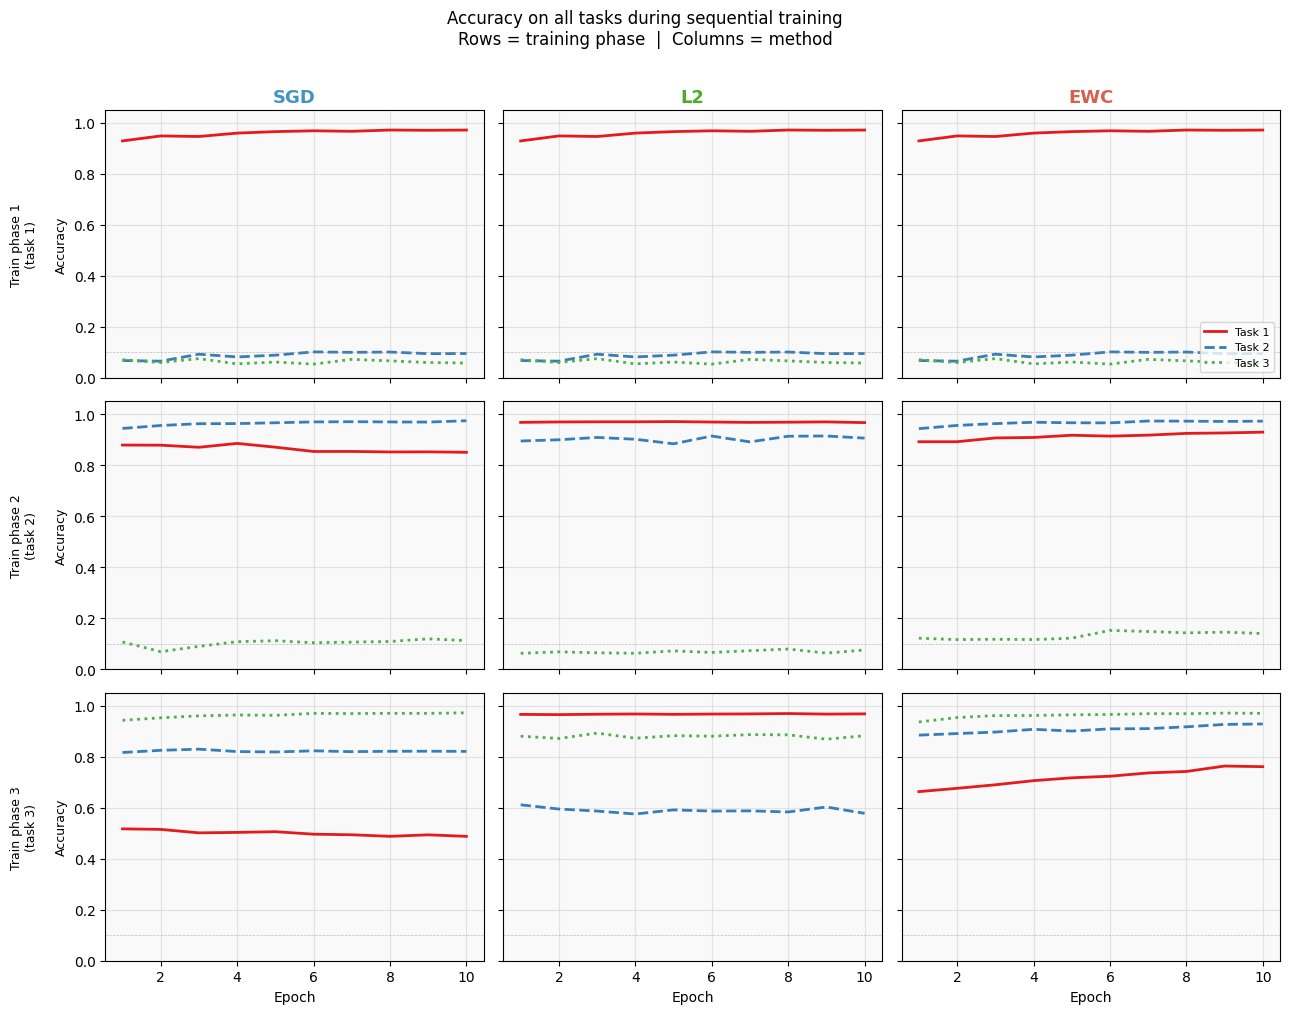

In [15]:
#Main experiment ───────────────────────────────────────────
print("\n" + "=" * 55)
print("Phase 2 : Expérience complète (3 tâches)")
print("=" * 55)

results = {}
LAM['ewc'] = 10000
for method in ['sgd', 'l2', 'ewc']:
    lam = LAM[method]
    print(f"\n{method.upper()}  (λ={lam})")
    torch.manual_seed(SEED)
    model  = make_model()
    opt    = optim.Adam(model.parameters(), lr=LR)
    fisher = None
    ewc_snap = None
    l2_snaps = []
    results[method] = []

    for phase, task_idx in enumerate([0, 1, 2]):
        train_loader, _ = tasks[task_idx]
        curves = [[] for _ in range(3)]

        for epoch in range(EPOCHS):
            if method == 'ewc':
                train_epoch(model, train_loader, opt, method, lam=lam,
                            old_snaps=ewc_snap, fisher=fisher)
            elif method == 'l2':
                train_epoch(model, train_loader, opt, method, lam=lam,
                            old_snaps=l2_snaps)
            else:
                train_epoch(model, train_loader, opt, method, lam=0)

            for i in range(3):
                curves[i].append(accuracy(model, tasks[i][1]))

        results[method].append(curves)

        new_snap = {n: p.clone().detach() for n, p in model.named_parameters()}
        l2_snaps.append(new_snap)
        ewc_snap = new_snap

        if method == 'ewc':
            new_f  = compute_fisher(model, train_loader)
            fisher = {n: fisher[n] + new_f[n] for n in new_f} if fisher else new_f

        print(f"  Phase {phase+1} done — final accs: "
              f"{[f'{curves[i][-1]:.2f}' for i in range(3)]}")

# ── Plot ─────────────────────────────────────────────────────
method_colors = {'sgd': '#4393c3', 'l2': '#4dac26', 'ewc': '#d6604d'}
task_styles   = ['-', '--', ':']
task_colors   = ['#e41a1c', '#377eb8', '#4daf4a']

fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
epochs = np.arange(1, EPOCHS + 1)

for col, method in enumerate(['sgd', 'l2', 'ewc']):
    for row, phase in enumerate([0, 1, 2]):
        ax = axes[row][col]
        curves = results[method][phase]

        for i in range(3):
            ax.plot(epochs, curves[i],
                    color=task_colors[i],
                    linestyle=task_styles[i],
                    linewidth=2,
                    label=f'Task {i+1}')

        ax.set_facecolor('#f9f9f9')
        ax.axhline(0.1, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

        if row == 0:
            ax.set_title(method.upper(), fontsize=13, fontweight='bold',
                         color=method_colors[method])
        if col == 0:
            ax.set_ylabel(f'Train phase {phase+1}\n(task {phase+1})\n\nAccuracy', fontsize=9)
        if row == 2:
            ax.set_xlabel('Epoch', fontsize=10)
        if row == 0 and col == 2:
            ax.legend(loc='lower right', fontsize=8)

        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)

plt.suptitle('Accuracy on all tasks during sequential training\n'
             'Rows = training phase  |  Columns = method', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [18]:
results = {}
LAM['ewc'] = 10000
method= 'ewc'
lam = LAM[method]
print(f"\n{method.upper()}  (λ={lam})")
torch.manual_seed(SEED)
model  = make_model()
opt    = optim.Adam(model.parameters(), lr=LR)
fisher = None
ewc_snap = None
l2_snaps = []
results[method] = []

for phase, task_idx in enumerate([0, 1, 2]):
    train_loader, _ = tasks[task_idx]
    curves = [[] for _ in range(3)]
    for epoch in range(EPOCHS):
        train_epoch(model, train_loader, opt, method, lam=lam, old_snaps=ewc_snap, fisher=fisher)
        
    for i in range(3):
        curves[i].append(accuracy(model, tasks[i][1]))
        
    results[method].append(curves)


    new_snap = {n: p.clone().detach() for n, p in model.named_parameters()}
    ewc_snap = new_snap


    new_f  = compute_fisher(model, train_loader)
    fisher = {n: fisher[n] + new_f[n] for n in new_f} if fisher else new_f

    print(f"  Phase {phase+1} done — final accs: "
            f"{[f'{curves[i][-1]:.2f}' for i in range(3)]}")


EWC  (λ=10000)
  Phase 1 done — final accs: ['0.97', '0.09', '0.07']
  Phase 2 done — final accs: ['0.86', '0.97', '0.14']
  Phase 3 done — final accs: ['0.70', '0.94', '0.97']


In [ ]:
# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
method_labels = {'sgd': 'SGD (baseline)', 'l2': f'L2 (λ={best_lam_l2})', 'ewc': f'EWC (λ={best_lam_ewc})'}
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, method in zip(axes, ['sgd', 'l2', 'ewc']):
    for phase_idx in range(3):
        curves = results[method][phase_idx]
        offset = phase_idx * EPOCHS
        for task_i in range(3):
            xs = range(offset, offset + EPOCHS)
            ax.plot(xs, curves[task_i], color=colors[task_i],
                    label=f'Task {task_i+1}' if phase_idx == 0 else None,
                    alpha=0.85 - 0.15 * phase_idx)
    for v in [EPOCHS, 2 * EPOCHS]:
        ax.axvline(v, linestyle='--', color='gray', alpha=0.4)
    ax.set_title(method_labels[method])
    ax.set_xlabel('Epoch (cumulative)')
    ax.set_ylabel('Test accuracy')
    ax.set_ylim(0, 1)
    ax.legend(loc='lower left')

# CV scores subplot
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
for ax, (method, scores, best) in zip(axes2, [
    ('L2',  cv_scores_l2,  best_lam_l2),
    ('EWC', cv_scores_ewc, best_lam_ewc),
]):
    lams = list(scores.keys())
    accs = [scores[l] for l in lams]
    bars = ax.bar([str(l) for l in lams], accs, color='steelblue', alpha=0.7)
    best_idx = lams.index(best)
    bars[best_idx].set_color('darkorange')
    ax.set_title(f'{method} — CV lambda selection')
    ax.set_xlabel('λ')
    ax.set_ylabel('Acc task 0 after task 1 training')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.annotate(f'best λ={best}', xy=(best_idx, accs[best_idx]),
                xytext=(best_idx + 0.5, accs[best_idx] - 0.06),
                arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

fig.tight_layout()
fig2.tight_layout()
